### Task 0


In [1]:
# Task a
from pathlib import Path
import json
import shutil
import subprocess
import urllib.request

DATA_DIR = Path("data")
MODEL_SMALL = "gemma3:270m"
MODEL_LARGE = "gemma3:4b"

print("Data folder exists:", DATA_DIR.exists())
print("Ollama installed:", shutil.which("ollama") is not None)

for model_name in [MODEL_SMALL, MODEL_LARGE]:
    print(f"Pulling/checking {model_name}...")
    subprocess.run(["ollama", "pull", model_name], check=True)

def ollama_generate(model_name, prompt, temperature=0.0, timeout=240):
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": temperature},
    }

    request = urllib.request.Request(
        "http://localhost:11434/api/generate",
        data=json.dumps(payload).encode("utf-8"),
        headers={"Content-Type": "application/json"},
        method="POST",
    )

    with urllib.request.urlopen(request, timeout=timeout) as response:
        result = json.loads(response.read().decode("utf-8"))

    return result["response"].strip()


# Task b
print("270m model response:")
print(ollama_generate(MODEL_SMALL, "Explain machine learning in one sentence."))


# Task c
print("4b model response:")
print(ollama_generate(
    MODEL_LARGE,
    "Explain why validation data is useful in one sentence.",
    timeout=300
))


Data folder exists: True
Ollama installed: True
Pulling/checking gemma3:270m...
Pulling/checking gemma3:4b...
270m model response:
Machine learning is a type of artificial intelligence that uses algorithms to learn from data without being explicitly programmed.
4b model response:
Validation data is crucial for assessing how well a trained machine learning model generalizes to unseen data, providing an unbiased estimate of its performance beyond the training set.


### Task 1


In [2]:
import pandas as pd

# Task a
emails_df = pd.read_csv(DATA_DIR / "emails.csv", sep="\t")
display(emails_df.head())

headline_col = "headline"
print("Using headline column:", headline_col)

def classify_email_headline(headline, model_name, temperature=0.0):
    prompt = f"""
Classify the following email headline into exactly one category.

Categories:
- spam: promotional, scam-like, suspicious, or unwanted marketing email
- work: legitimate workplace, colleague, client, meeting, project, or business email
- unknown: too vague or ambiguous to classify from the headline alone

Return only one lowercase word: spam, work, or unknown.

Headline: {headline}
Classification:
""".strip()

    response = ollama_generate(model_name, prompt, temperature=temperature)
    label = response.strip().lower()
    label = label.replace("classification:", "").strip()
    label = label.strip(" `\"'.:,;()[]{}")

    if label in ["spam", "work", "unknown"]:
        return label

    words = label.replace("\n", " ").split()
    for possible_label in ["spam", "work", "unknown"]:
        if possible_label in words:
            return possible_label

    return "unknown"


# Task b
task1_results = emails_df[[headline_col]].copy()
task1_results["gemma3_270m"] = [
    classify_email_headline(headline, MODEL_SMALL, temperature=0.0)
    for headline in emails_df[headline_col]
]

print("Small model results:")
display(task1_results)


# Task c
task1_results["gemma3_4b"] = [
    classify_email_headline(headline, MODEL_LARGE, temperature=0.0)
    for headline in emails_df[headline_col]
]

print("Small and large model results:")
display(task1_results)

disagreements = task1_results[task1_results["gemma3_270m"] != task1_results["gemma3_4b"]]
print("Number of disagreements between the models:", len(disagreements))
display(disagreements)


,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review


Using headline column: headline
Small model results:


,headline,gemma3_270m
0,URGENT: Your account will be suspended within ...,spam
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,spam
5,"Q3 budget report attached, please review by Fr...",spam
6,Reminder: Annual performance review scheduled ...,spam
7,"Updated draft of the manuscript, comments welcome",spam
8,Quick question about last week,spam
9,Following up,spam


Small and large model results:


,headline,gemma3_270m,gemma3_4b
0,URGENT: Your account will be suspended within ...,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam
4,Meeting agenda for Thursday's project review,spam,work
5,"Q3 budget report attached, please review by Fr...",spam,work
6,Reminder: Annual performance review scheduled ...,spam,work
7,"Updated draft of the manuscript, comments welcome",spam,work
8,Quick question about last week,spam,work
9,Following up,spam,work


Number of disagreements between the models: 7


,headline,gemma3_270m,gemma3_4b
4,Meeting agenda for Thursday's project review,spam,work
5,"Q3 budget report attached, please review by Fr...",spam,work
6,Reminder: Annual performance review scheduled ...,spam,work
7,"Updated draft of the manuscript, comments welcome",spam,work
8,Quick question about last week,spam,work
9,Following up,spam,work
11,Are you available?,spam,unknown


The 270m model performed poorly in my run because it classified every headline as `spam`, including clearly work-related messages such as the meeting agenda, budget report, and performance review. The larger Gemma 3 model was more useful because it identified the work-related headlines and marked the vaguest headline as `unknown`.


In [3]:
# Task d
repeated_email_results = emails_df[[headline_col]].copy()

for run_number in range(1, 4):
    repeated_email_results[f"270m_run_{run_number}"] = [
        classify_email_headline(headline, MODEL_SMALL, temperature=0.7)
        for headline in emails_df[headline_col]
    ]

    repeated_email_results[f"4b_run_{run_number}"] = [
        classify_email_headline(headline, MODEL_LARGE, temperature=0.7)
        for headline in emails_df[headline_col]
    ]

display(repeated_email_results)

for model_label in ["270m", "4b"]:
    run_columns = [f"{model_label}_run_{i}" for i in range(1, 4)]
    varied_rows = repeated_email_results[run_columns].nunique(axis=1) > 1
    print(f"{model_label}: {varied_rows.sum()} headline(s) changed classification across runs.")

    if varied_rows.any():
        display(repeated_email_results.loc[varied_rows, [headline_col] + run_columns])


,headline,270m_run_1,4b_run_1,270m_run_2,4b_run_2,270m_run_3,4b_run_3
0,URGENT: Your account will be suspended within ...,spam,spam,spam,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam,spam,spam,spam
4,Meeting agenda for Thursday's project review,spam,work,spam,work,spam,work
5,"Q3 budget report attached, please review by Fr...",spam,work,spam,work,spam,work
6,Reminder: Annual performance review scheduled ...,spam,work,spam,work,spam,work
7,"Updated draft of the manuscript, comments welcome",spam,work,spam,work,spam,work
8,Quick question about last week,spam,work,spam,work,spam,work
9,Following up,spam,work,spam,work,spam,work


270m: 0 headline(s) changed classification across runs.
4b: 0 headline(s) changed classification across runs.


In the repeated runs, neither model changed classification across the three runs. Even though `temperature=0.7` makes the model output less deterministic, the prompt constrained the output to only three labels, so the models still returned stable classifications in this run. In general, variation is more likely for vague headlines where more than one classification could be reasonable.



### Task 2


In [4]:
import json
import pandas as pd

# Task a
news_df = pd.read_csv(DATA_DIR / "news.csv", sep="\t")
display(news_df.head())

headline_col = "headline"
print("Using headline column:", headline_col)

def classify_news_headline(headline, model_name=MODEL_LARGE, temperature=0.0):
    prompt = f"""
Classify the following financial news headline.

Choose exactly one topic:
- earnings
- mergers
- regulation
- macroeconomics

Choose exactly one sentiment:
- positive
- negative
- neutral

Return only valid JSON with exactly these keys:
{{"topic": "...", "sentiment": "..."}}

Headline: {headline}
JSON:
""".strip()

    response = ollama_generate(model_name, prompt, temperature=temperature, timeout=240)
    start = response.find("{")
    end = response.rfind("}")

    if start == -1 or end == -1:
        raise ValueError(f"No JSON object found in response: {response}")

    result = json.loads(response[start:end + 1])
    topic = result["topic"].strip().lower()
    sentiment = result["sentiment"].strip().lower()

    if topic not in ["earnings", "mergers", "regulation", "macroeconomics"]:
        raise ValueError(f"Unexpected topic: {topic}")

    if sentiment not in ["positive", "negative", "neutral"]:
        raise ValueError(f"Unexpected sentiment: {sentiment}")

    return json.dumps({"topic": topic, "sentiment": sentiment})


# Task b
news_results = news_df[[headline_col]].copy()

topics = []
sentiments = []

for headline in news_df[headline_col]:
    result = json.loads(classify_news_headline(headline, MODEL_LARGE))
    topics.append(result["topic"])
    sentiments.append(result["sentiment"])

news_results["topic"] = topics
news_results["sentiment"] = sentiments
display(news_results)


# Task c
browser_prompt = """Classify each financial news headline below.

Choose exactly one topic for each headline from:
earnings, mergers, regulation, macroeconomics.

Choose exactly one sentiment for each headline from:
positive, negative, neutral.

Return a markdown table with columns:
headline, topic, sentiment.

Headlines:
"""

browser_prompt += "\n".join(
    f"{i + 1}. {headline}"
    for i, headline in enumerate(news_df[headline_col])
)

print(browser_prompt)


,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...


Using headline column: headline


,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,neutral
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,neutral
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,neutral
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


Classify each financial news headline below.

Choose exactly one topic for each headline from:
earnings, mergers, regulation, macroeconomics.

Choose exactly one sentiment for each headline from:
positive, negative, neutral.

Return a markdown table with columns:
headline, topic, sentiment.

Headlines:
1. Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%
2. Helvora Pharmaceuticals misses earnings forecast amid weak generics demand
3. Aurelis Bank reports steady quarterly profit, in line with analyst expectations
4. Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal
5. Antitrust regulators block proposed merger between Solenta and Marvex Energy
6. Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG
7. New EU AI Act compliance rules expected to raise costs for Lumavex by 12%
8. Finnish FSA grants Norvik Capital expanded licence for cross-border operations
9. Eurozone inflation cools to 2.1%, easing pressure on Drava Holding

I gave the same headlines and the same topic and sentiment options to ChatGPT. It produced the following results:

| headline | topic | sentiment |
|---|---|---|
| Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% | earnings | positive |
| Helvora Pharmaceuticals misses earnings forecast amid weak generics demand | earnings | negative |
| Aurelis Bank reports steady quarterly profit, in line with analyst expectations | earnings | neutral |
| Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal | mergers | positive |
| Antitrust regulators block proposed merger between Solenta and Marvex Energy | mergers | negative |
| Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG | mergers | neutral |
| New EU AI Act compliance rules expected to raise costs for Lumavex by 12% | regulation | negative |
| Finnish FSA grants Norvik Capital expanded licence for cross-border operations | regulation | positive |
| Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs | macroeconomics | positive |
| Rising interest rates weigh on Tessaro Real Estate as financing costs climb | macroeconomics | negative |

Compared with the Ollama results, ChatGPT appears more accurate overall. Both models classified several straightforward examples correctly, such as the earnings miss as negative and rising interest rates as macroeconomics and negative. Some differences are borderline: for example, classifying the blocked merger as `regulation` is defensible because antitrust regulators are the actors, but `mergers` better captures the main event category. ChatGPT also handled the positive or neutral business implications more consistently, such as the acquisition deal, expanded licence, and cooling inflation.


### Task 3


Shape: (4119, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.id

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,4119.0,NaN,NaN,NaN,40.11362,10.313362,18.0,32.0,38.0,47.0,88.0
job,4119,12,admin.,1012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,4119,4,married,2509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,4119,8,university.degree,1264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,4119,3,no,3315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,4119,3,yes,2175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,4119,3,no,3349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,4119,2,cellular,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,4119,10,may,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,4119,5,thu,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,percent
y,,
no,3668,89.05
yes,451,10.95


,unknown_count,unknown_percent
default,803,19.50
education,167,4.05
housing,105,2.55
loan,105,2.55
job,39,0.95
marital,11,0.27


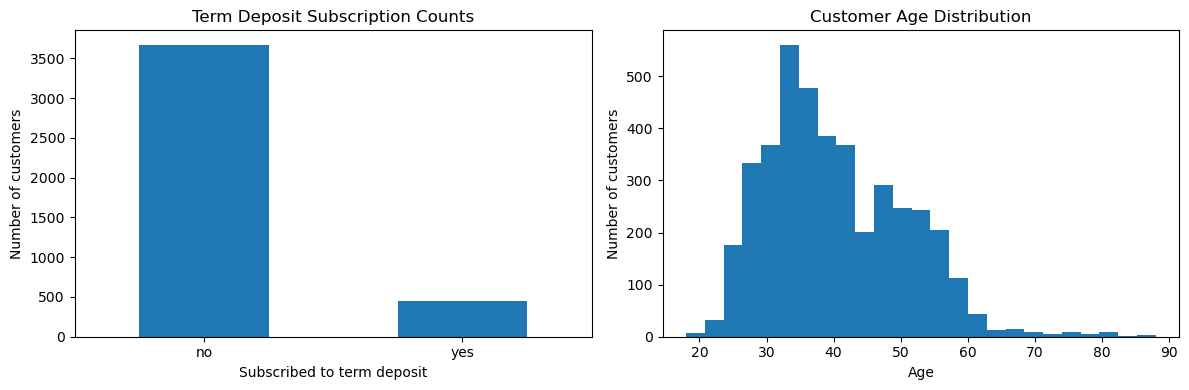

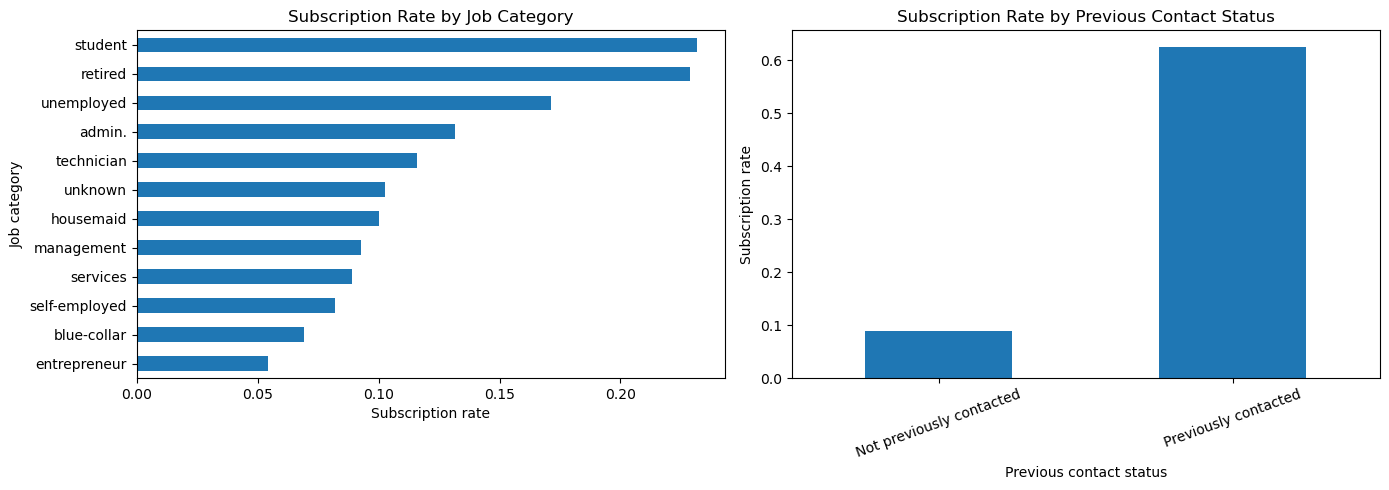

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Task a
bank_path = DATA_DIR / "bank-additional.csv"
bank_df = pd.read_csv(bank_path, sep=";")

print("Shape:", bank_df.shape)
display(bank_df.head())

print("Dataset information:")
bank_df.info()

display(bank_df.describe(include="all").T)

target_distribution = bank_df["y"].value_counts().rename_axis("y").to_frame("count")
target_distribution["percent"] = (target_distribution["count"] / len(bank_df) * 100).round(2)
display(target_distribution)

categorical_columns = bank_df.select_dtypes(include=["object"]).columns.tolist()
unknown_counts = (bank_df[categorical_columns] == "unknown").sum().sort_values(ascending=False)
unknown_counts = unknown_counts[unknown_counts > 0].to_frame("unknown_count")
unknown_counts["unknown_percent"] = (unknown_counts["unknown_count"] / len(bank_df) * 100).round(2)
display(unknown_counts)

eda_df = bank_df.copy()
eda_df["subscribed"] = eda_df["y"].map({"no": 0, "yes": 1})
eda_df["previously_contacted"] = eda_df["pdays"].ne(999)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_distribution["count"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Term Deposit Subscription Counts")
axes[0].set_xlabel("Subscribed to term deposit")
axes[0].set_ylabel("Number of customers")
axes[0].tick_params(axis="x", rotation=0)

bank_df["age"].plot(kind="hist", bins=25, ax=axes[1])
axes[1].set_title("Customer Age Distribution")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Number of customers")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

job_subscription = eda_df.groupby("job")["subscribed"].mean().sort_values()
job_subscription.plot(kind="barh", ax=axes[0])
axes[0].set_title("Subscription Rate by Job Category")
axes[0].set_xlabel("Subscription rate")
axes[0].set_ylabel("Job category")

pdays_subscription = eda_df.groupby("previously_contacted")["subscribed"].mean()
pdays_subscription.index = ["Not previously contacted", "Previously contacted"]
pdays_subscription.plot(kind="bar", ax=axes[1])
axes[1].set_title("Subscription Rate by Previous Contact Status")
axes[1].set_xlabel("Previous contact status")
axes[1].set_ylabel("Subscription rate")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


The dataset is imbalanced because most customers did not subscribe to a term deposit. The dataset also uses the string `unknown` in categorical columns, so checking only `NaN` values would miss part of the data quality picture.


In [8]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Task b
target_col = "y"
X = bank_df.drop(columns=[target_col, "duration"])
y = bank_df[target_col].map({"no": 0, "yes": 1})

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot_encoder)
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Train/validation/test sizes:", len(X_train), len(X_val), len(X_test))


Numeric features: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Train/validation/test sizes: 2471 824 824


I dropped `duration` before modeling because it is only known after the phone call ends. Including it would leak information that would not be available when predicting future customers.


This is a classification task because the target variable `y` has two categories: `yes` and `no`. I chose logistic regression as a simple baseline, random forest because it can model non-linear relationships, and gradient boosting because it often performs well on tabular classification problems.


In [9]:
# Task c
model_specs = {
    "Logistic regression": {
        "pipeline": Pipeline([
            ("preprocess", preprocessor),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
        ]),
        "params": {"model__C": [0.1, 1.0, 10.0]}
    },
    "Random forest": {
        "pipeline": Pipeline([
            ("preprocess", preprocessor),
            ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [10, 20, None],
            "model__min_samples_leaf": [1, 5]
        }
    },
    "Gradient boosting": {
        "pipeline": Pipeline([
            ("preprocess", preprocessor),
            ("model", GradientBoostingClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3]
        }
    }
}

def get_scores(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    return model.decision_function(X_data)

def evaluate_model(model, X_data, y_true):
    y_pred = model.predict(X_data)
    y_score = get_scores(model, X_data)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "average_precision": average_precision_score(y_true, y_score)
    }

holdout_rows = []
holdout_best_models = {}

for model_name, spec in model_specs.items():
    best_score = -np.inf
    best_model = None
    best_params = None

    for params in ParameterGrid(spec["params"]):
        model = clone(spec["pipeline"]).set_params(**params)
        model.fit(X_train, y_train)
        val_metrics = evaluate_model(model, X_val, y_val)

        holdout_rows.append({
            "model": model_name,
            "params": params,
            **val_metrics
        })

        if val_metrics["average_precision"] > best_score:
            best_score = val_metrics["average_precision"]
            best_model = model
            best_params = params

    final_model = clone(best_model)
    final_model.fit(X_train_val, y_train_val)
    holdout_best_models[model_name] = {
        "model": final_model,
        "params": best_params,
        "validation_average_precision": best_score
    }

holdout_results = pd.DataFrame(holdout_rows).sort_values(
    ["model", "average_precision"],
    ascending=[True, False]
)

display(holdout_results.groupby("model").head(3))


,model,params,accuracy,precision,recall,f1,roc_auc,average_precision
17,Gradient boosting,"{'model__learning_rate': 0.05, 'model__max_dep...",0.904126,0.720000,0.200000,0.313043,0.779625,0.467006
18,Gradient boosting,"{'model__learning_rate': 0.05, 'model__max_dep...",0.904126,0.703704,0.211111,0.324786,0.781343,0.463783
21,Gradient boosting,"{'model__learning_rate': 0.1, 'model__max_dept...",0.902913,0.678571,0.211111,0.322034,0.779935,0.456646
1,Logistic regression,{'model__C': 1.0},0.839806,0.360000,0.600000,0.450000,0.756676,0.434250
0,Logistic regression,{'model__C': 0.1},0.844660,0.371622,0.611111,0.462185,0.763533,0.428090
2,Logistic regression,{'model__C': 10.0},0.834951,0.348684,0.588889,0.438017,0.750727,0.426808
10,Random forest,"{'model__max_depth': 20, 'model__min_samples_l...",0.870146,0.422018,0.511111,0.462312,0.774841,0.433736
14,Random forest,"{'model__max_depth': None, 'model__min_samples...",0.870146,0.422018,0.511111,0.462312,0.775310,0.431404
9,Random forest,"{'model__max_depth': 20, 'model__min_samples_l...",0.866505,0.410714,0.511111,0.455446,0.776673,0.430596


In [10]:
# Task d
holdout_test_results = []

for model_name, result in holdout_best_models.items():
    metrics = evaluate_model(result["model"], X_test, y_test)
    holdout_test_results.append({
        "selection_method": "train/validation/test split",
        "model": model_name,
        "best_params": result["params"],
        **metrics
    })

holdout_test_results = pd.DataFrame(holdout_test_results)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_best_models = {}
cv_rows = []

for model_name, spec in model_specs.items():
    search = GridSearchCV(
        spec["pipeline"],
        spec["params"],
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        refit=True
    )

    search.fit(X_train_val, y_train_val)
    cv_best_models[model_name] = {
        "model": search.best_estimator_,
        "params": search.best_params_,
        "cv_average_precision": search.best_score_
    }

    cv_rows.append({
        "model": model_name,
        "best_params": search.best_params_,
        "cv_average_precision": search.best_score_
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_average_precision", ascending=False)
display(cv_results)

cv_test_results = []

for model_name, result in cv_best_models.items():
    metrics = evaluate_model(result["model"], X_test, y_test)
    cv_test_results.append({
        "selection_method": "5-fold cross-validation",
        "model": model_name,
        "best_params": result["params"],
        **metrics
    })

cv_test_results = pd.DataFrame(cv_test_results)
all_results = pd.concat([holdout_test_results, cv_test_results], ignore_index=True)
all_results = all_results.sort_values("average_precision", ascending=False)

display(all_results)


,model,best_params,cv_average_precision
2,Gradient boosting,"{'model__learning_rate': 0.05, 'model__max_dep...",0.457186
1,Random forest,"{'model__max_depth': 10, 'model__min_samples_l...",0.442250
0,Logistic regression,{'model__C': 0.1},0.429750


,selection_method,model,best_params,accuracy,precision,recall,f1,roc_auc,average_precision
1,train/validation/test split,Random forest,"{'model__max_depth': 20, 'model__min_samples_l...",0.877427,0.442105,0.466667,0.454054,0.773585,0.440630
2,train/validation/test split,Gradient boosting,"{'model__learning_rate': 0.05, 'model__max_dep...",0.904126,0.739130,0.188889,0.300885,0.773804,0.436315
4,5-fold cross-validation,Random forest,"{'model__max_depth': 10, 'model__min_samples_l...",0.875000,0.438095,0.511111,0.471795,0.772041,0.428218
5,5-fold cross-validation,Gradient boosting,"{'model__learning_rate': 0.05, 'model__max_dep...",0.904126,0.720000,0.200000,0.313043,0.785543,0.419301
3,5-fold cross-validation,Logistic regression,{'model__C': 0.1},0.831311,0.341935,0.588889,0.432653,0.779867,0.418732
0,train/validation/test split,Logistic regression,{'model__C': 1.0},0.833738,0.342282,0.566667,0.426778,0.759885,0.409102


In my run, the best single test-set average precision came from the random forest selected with the train/validation/test split, but the margin over the cross-validated random forest was small. Cross-validation is more trustworthy for model selection on this dataset because there are only 4,119 rows and the positive class is small, so a single validation split can be noisy.


Best single test-set model: Random forest
Selection method: train/validation/test split
Best parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 5, 'model__n_estimators': 400}
              precision    recall  f1-score   support

          no       0.93      0.93      0.93       734
         yes       0.44      0.47      0.45        90

    accuracy                           0.88       824
   macro avg       0.69      0.70      0.69       824
weighted avg       0.88      0.88      0.88       824



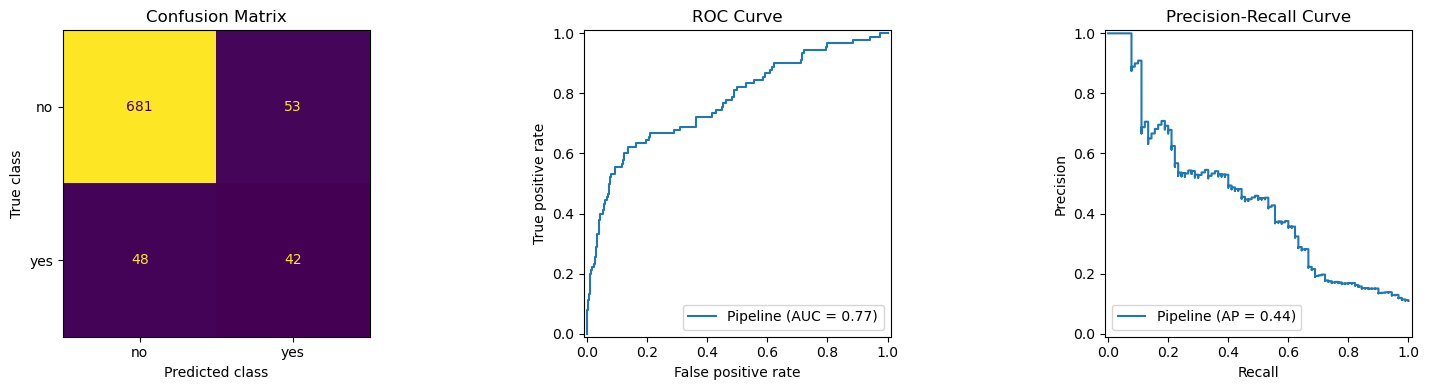

In [11]:
# Task e
best_result = all_results.iloc[0]
best_method = best_result["selection_method"]
best_model_name = best_result["model"]

if best_method == "train/validation/test split":
    best_model = holdout_best_models[best_model_name]["model"]
else:
    best_model = cv_best_models[best_model_name]["model"]

print("Best single test-set model:", best_model_name)
print("Selection method:", best_method)
print("Best parameters:", best_result["best_params"])

print(classification_report(
    y_test,
    best_model.predict(X_test),
    target_names=["no", "yes"],
    zero_division=0
))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["no", "yes"],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("True class")

RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=axes[2])
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")

plt.tight_layout()
plt.show()


Accuracy is not enough for this task because most customers did not subscribe. I therefore compare accuracy with precision, recall, F1, ROC AUC, and especially average precision for the minority `yes` class. Random forest and gradient boosting are effectively close, while logistic regression is mainly a baseline. If choosing only by the best single test-set average precision, random forest is strongest; if choosing by consistency across validation and cross-validation, gradient boosting is also defensible.


## Statement of use of AI

I used AI assistance to help structure the assignment, debug errors, and draft parts of the Python code and written explanations. I reviewed the outputs and adjusted the answers based on the actual notebook results.
